[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adaptive-intelligent-robotics/QDax/blob/main/examples/pgame.ipynb)

# Optimizing with PGAME in JAX

This notebook shows how to use QDax to find diverse and performing controllers in MDPs with [Policy Gradient Assisted MAP-Elites](https://hal.archives-ouvertes.fr/hal-03135723v2/file/PGA_MAP_Elites_GECCO.pdf).
It can be run locally or on Google Colab. We recommend to use a GPU. This notebook will show:

- how to define the problem
- how to create the PGAME emitter
- how to create a Map-elites instance
- which functions must be defined before training
- how to launch a certain number of training steps
- how to visualize the results of the training process

## Installation

You will need Python 3.11 or later, and a working JAX installation. For example, you can install JAX with:

In [1]:
%pip install -U "jax[cuda]"

/Users/behradkoohy/Development/QDaxBase/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


Then, install QDax from PyPI:

In [2]:
%pip install -U "qdax[examples]"

/Users/behradkoohy/Development/QDaxBase/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os

from IPython.display import clear_output
import functools
import time

import jax
import jax.numpy as jnp

from qdax.core.map_elites import MAPElites
from qdax.core.containers.mapelites_repertoire import compute_cvt_centroids
import qdax.tasks.brax as environments
from qdax.tasks.brax.env_creators import scoring_function_brax_envs as scoring_function
from qdax.core.neuroevolution.buffers.buffer import QDTransition
from qdax.core.neuroevolution.networks.networks import MLP
from qdax.core.emitters.mutation_operators import isoline_variation
from qdax.utils.plotting import plot_map_elites_results

from qdax.core.emitters.pga_me_emitter import PGAMEConfig, PGAMEEmitter
from qdax.utils.metrics import CSVLogger, default_qd_metrics

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


In [4]:
#@title QD Training Definitions Fields
#@markdown ---
env_name = 'halfcheetah_uni'#@param['ant_uni', 'hopper_uni', 'walker_uni', 'halfcheetah_uni', 'humanoid_uni', 'ant_omni', 'humanoid_omni']
episode_length = 1000 #@param {type:"integer"}
num_iterations = 250 #@param {type:"integer"}
seed = 1 #@param {type:"integer"}
policy_hidden_layer_sizes = (256, 256) #@param {type:"raw"}
iso_sigma = 0.005 #@param {type:"number"}
line_sigma = 0.05 #@param {type:"number"}
num_init_cvt_samples = 50000 #@param {type:"integer"}
num_centroids = 1024 #@param {type:"integer"}
min_descriptor = 0. #@param {type:"number"}
max_descriptor = 1.0 #@param {type:"number"}

proportion_mutation_ga = 0.5 #@param {type:"number"}

# TD3 params
env_batch_size = 10 #@param {type:"number"}
replay_buffer_size = 1000000 #@param {type:"number"}
critic_hidden_layer_size = (256, 256) #@param {type:"raw"}
critic_learning_rate = 3e-4 #@param {type:"number"}
greedy_learning_rate = 3e-4 #@param {type:"number"}
policy_learning_rate = 1e-3 #@param {type:"number"}
noise_clip = 0.5 #@param {type:"number"}
policy_noise = 0.2 #@param {type:"number"}
discount = 0.99 #@param {type:"number"}
reward_scaling = 1.0 #@param {type:"number"}
transitions_batch_size = 256 #@param {type:"number"}
# soft_tau_update = 0.005 #@param {type:"number"}
soft_tau_update = 0.005 #@param {type:"number"}
num_critic_training_steps = 300 #@param {type:"number"}
num_pg_training_steps = 100 #@param {type:"number"}
policy_delay = 2 #@param {type:"number"}
#@markdown ---

## Init environment, policy, population params, init states of the env

Define the environment in which the policies will be trained. In this notebook, we focus on controllers learning to move a robot in a physical simulation. We also define the shared policy, that every individual in the population will use. Once the policy is defined, all individuals are defined by their parameters, that corresponds to their genotype.

In [5]:
# Init environment
env = environments.create(env_name, episode_length=episode_length, backend='mjx')
reset_fn = jax.jit(env.reset)

# Init a random key
key = jax.random.key(seed)

# Init policy network
policy_layer_sizes = policy_hidden_layer_sizes + (env.action_size,)
policy_network = MLP(
    layer_sizes=policy_layer_sizes,
    kernel_init=jax.nn.initializers.lecun_uniform(),
    final_activation=jnp.tanh,
)

# Init population of controllers
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, num=env_batch_size)
fake_batch = jnp.zeros(shape=(env_batch_size, env.observation_size))
init_variables = jax.vmap(policy_network.init)(keys, fake_batch)

/Users/behradkoohy/Development/QDaxBase/.venv/lib/python3.12/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


## Define the way the policy interacts with the env

In [6]:
# Define the function to play a step with the policy in the environment
def play_step_fn(
    env_state,
    policy_params,
    key,
):
    """
    Play an environment step and return the updated state and the transition.
    """

    actions = policy_network.apply(policy_params, env_state.obs)

    state_desc = env_state.info["state_descriptor"]
    next_state = env.step(env_state, actions)

    transition = QDTransition(
        obs=env_state.obs,
        next_obs=next_state.obs,
        rewards=next_state.reward,
        dones=next_state.done,
        actions=actions,
        truncations=next_state.info["truncation"],
        state_desc=state_desc,
        next_state_desc=next_state.info["state_descriptor"],
    )

    return next_state, policy_params, key, transition

## Define the scoring function and the way metrics are computed

The scoring function is used in the evaluation step to determine the fitness and descriptor of each individual.

In [7]:
# Prepare the scoring function
descriptor_extraction_fn = environments.descriptor_extractor[env_name]
scoring_fn = functools.partial(
    scoring_function,
    episode_length=episode_length,
    play_reset_fn=reset_fn,
    play_step_fn=play_step_fn,
    descriptor_extractor=descriptor_extraction_fn,
)

# Get minimum reward value to make sure qd_score are positive
reward_offset = environments.reward_offset[env_name]

# Define a metrics function
metrics_function = functools.partial(
    default_qd_metrics,
    qd_offset=reward_offset * episode_length,
)

## Define the emitter: PG Emitter

The emitter is used to evolve the population at each mutation step. In this example, the emitter is the Policy Gradient emitter, the one used in Policy Gradient Assisted Map Elites. It trains a critic with the transitions experienced in the environment and uses the critic to apply Policy Gradient updates to the policies evolved.

In [8]:
# Define the PG-emitter config
pga_emitter_config = PGAMEConfig(
    env_batch_size=env_batch_size,
    batch_size=transitions_batch_size,
    proportion_mutation_ga=proportion_mutation_ga,
    critic_hidden_layer_size=critic_hidden_layer_size,
    critic_learning_rate=critic_learning_rate,
    greedy_learning_rate=greedy_learning_rate,
    policy_learning_rate=policy_learning_rate,
    noise_clip=noise_clip,
    policy_noise=policy_noise,
    discount=discount,
    reward_scaling=reward_scaling,
    replay_buffer_size=replay_buffer_size,
    soft_tau_update=soft_tau_update,
    num_critic_training_steps=num_critic_training_steps,
    num_pg_training_steps=num_pg_training_steps,
    policy_delay=policy_delay,
)

In [9]:
# Get the emitter
variation_fn = functools.partial(
    isoline_variation, iso_sigma=iso_sigma, line_sigma=line_sigma
)

pg_emitter = PGAMEEmitter(
    config=pga_emitter_config,
    policy_network=policy_network,
    env=env,
    variation_fn=variation_fn,
)

## Instantiate and initialise the MAP Elites algorithm

In [10]:
# Instantiate MAP Elites
map_elites = MAPElites(
    scoring_function=scoring_fn,
    emitter=pg_emitter,
    metrics_function=metrics_function,
)

# Compute the centroids
key, subkey = jax.random.split(key)
centroids = compute_cvt_centroids(
    num_descriptors=env.descriptor_length,
    num_init_cvt_samples=num_init_cvt_samples,
    num_centroids=num_centroids,
    minval=min_descriptor,
    maxval=max_descriptor,
    key=subkey,
)

# compute initial repertoire
key, subkey = jax.random.split(key)
repertoire, emitter_state, init_metrics = map_elites.init(
    init_variables, centroids, subkey
)

In [11]:
log_period = 1
num_loops = num_iterations // log_period

# Initialize metrics
metrics = {key: jnp.array([]) for key in ["iteration", "qd_score", "coverage", "max_fitness", "time"]}

# Set up init metrics
init_metrics = jax.tree.map(lambda x: jnp.array([x]) if x.shape == () else x, init_metrics)
init_metrics["iteration"] = jnp.array([0], dtype=jnp.int32)
init_metrics["time"] = jnp.array([0.0])  # No time recorded for initialization

# Convert init_metrics to match the metrics dictionary structure
metrics = jax.tree.map(lambda metric, init_metric: jnp.concatenate([metric, init_metric], axis=0), metrics, init_metrics)

# Initialize CSV logger
csv_logger = CSVLogger(
    "pgame-logs.csv",
    header=list(metrics.keys())
)

# Main loop
map_elites_scan_update = map_elites.scan_update
for i in range(num_loops):
    start_time = time.time()
    (
        repertoire,
        emitter_state,
        key,
    ), current_metrics = jax.lax.scan(
        map_elites_scan_update,
        (repertoire, emitter_state, key),
        (),
        length=log_period,
    )
    timelapse = time.time() - start_time

    # Metrics
    current_metrics["iteration"] = jnp.arange(1+log_period*i, 1+log_period*(i+1), dtype=jnp.int32)
    current_metrics["time"] = jnp.repeat(timelapse, log_period)
    metrics = jax.tree.map(lambda metric, current_metric: jnp.concatenate([metric, current_metric], axis=0), metrics, current_metrics)

    # Log
    csv_logger.log(jax.tree.map(lambda x: x[-1], metrics))

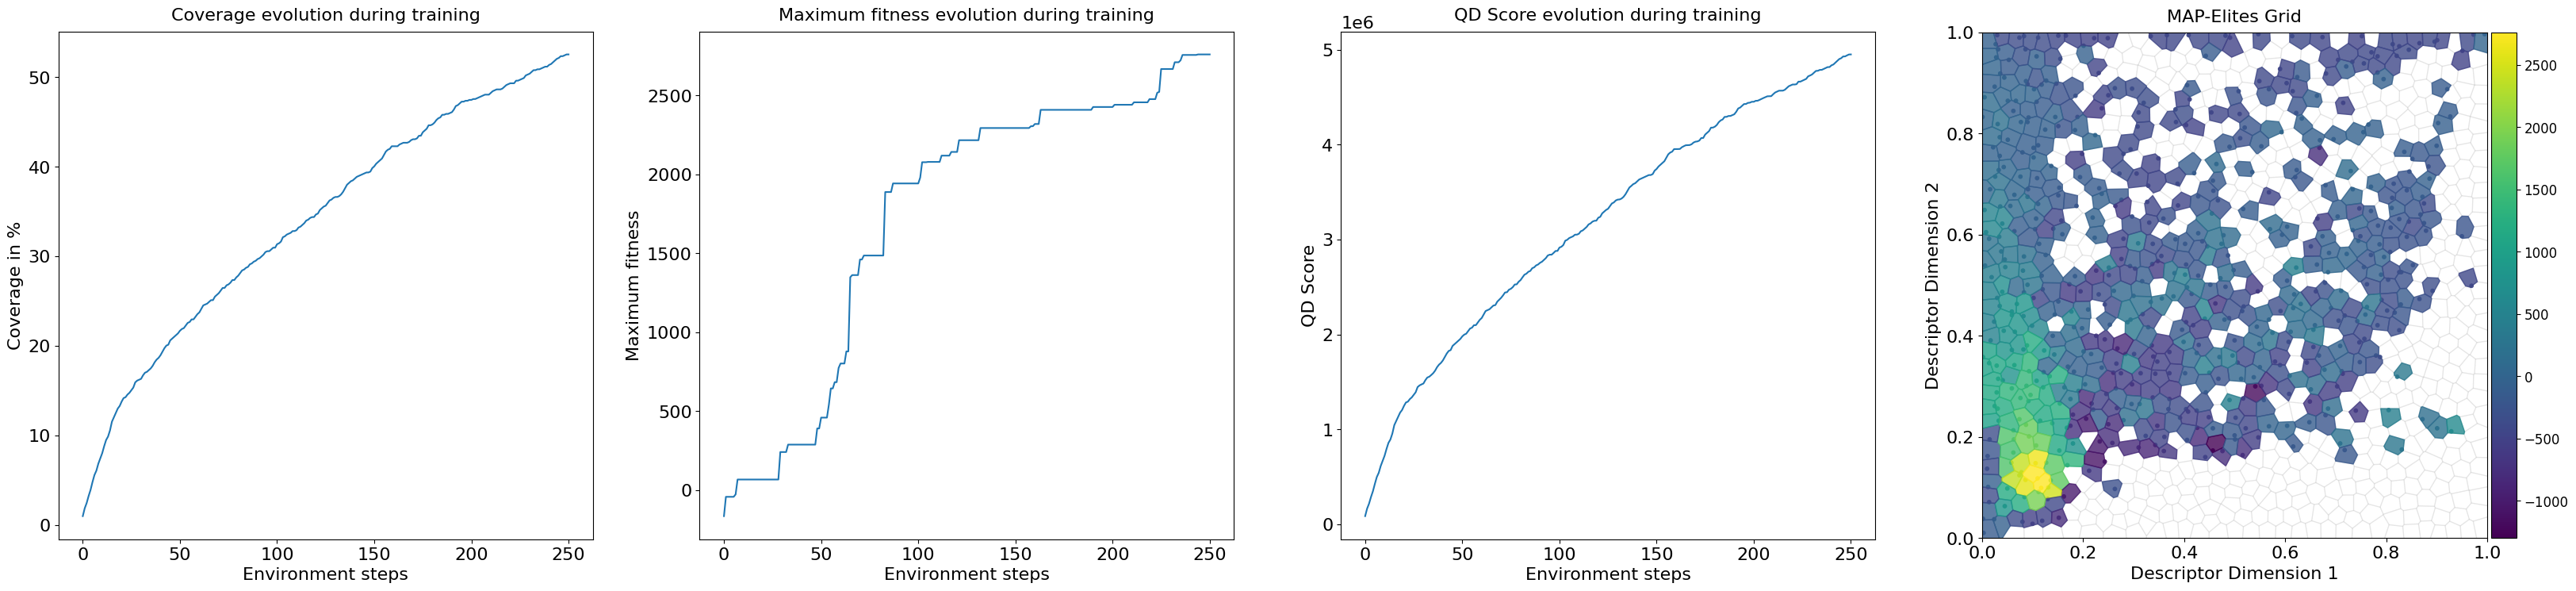

In [12]:
#@title Visualization

# Create the x-axis array
env_steps = metrics["iteration"]

%matplotlib inline
# Create the plots and the grid
fig, axes = plot_map_elites_results(env_steps=env_steps, metrics=metrics, repertoire=repertoire, min_descriptor=min_descriptor, max_descriptor=max_descriptor)